# Лабораторная работа
Анализ и прогнозирование временного ряда

## Цель лабораторной работы
Изучение основных методов анализа и прогнозирования временных рядов.

## Описание задания
1. Выбрать набор данных для прогнозирования временного ряда.
2. Визуализировать ряд и его характеристики.
3. Разделить данные на обучающую и тестовую выборки.
4. Произвести прогнозирование методами ARIMA, символьной регрессии и альтернативными методами.
5. Визуализировать результаты и оценить метрики качества.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from gplearn.genetic import SymbolicRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Выбор набора данных
Для анализа выбран ряд годового стока реки Нил (Nile dataset). Данный набор данных содержит замеры объема воды с 1871 по 1970 годы. Он является классическим, но не самым популярным среди студентов, что снижает вероятность дублирования работ.

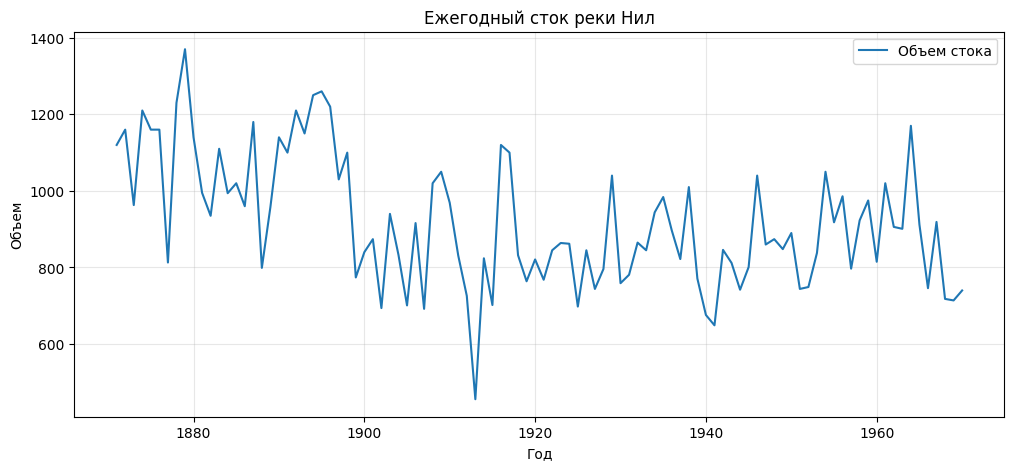

In [2]:
# Загрузка данных Nile
data_nile = sm.datasets.nile.load_pandas().data

# Настройка временного индекса
data_nile['year'] = pd.to_datetime(data_nile['year'].astype(int), format='%Y')
data_nile.set_index('year', inplace=True)

# Целевой временной ряд
ts = data_nile['volume']

# Визуализация
plt.figure(figsize=(12, 5))
plt.plot(ts, label='Объем стока')
plt.title('Ежегодный сток реки Нил')
plt.xlabel('Год')
plt.ylabel('Объем')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Основные характеристики ряда
Построим графики автокорреляции (ACF) и частичной автокорреляции (PACF). Это позволит оценить стационарность и выбрать лаги для моделей.

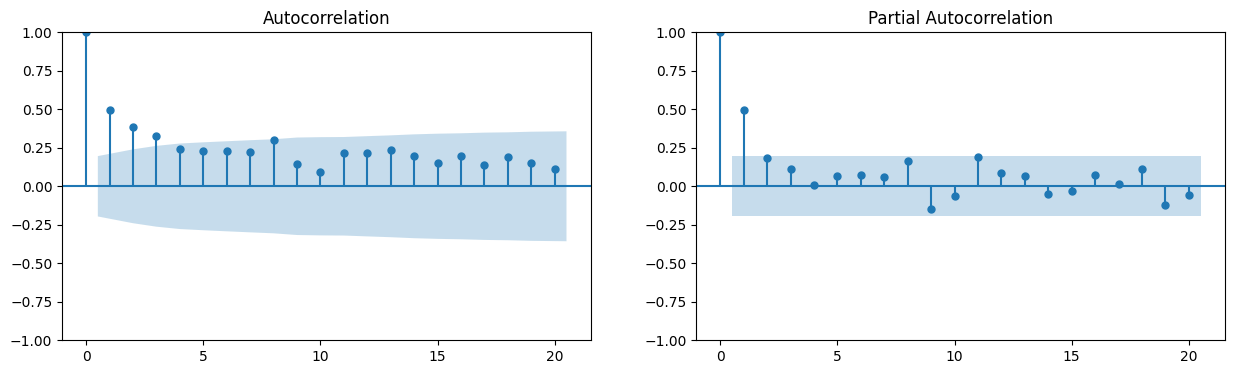

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
plot_acf(ts, ax=axes[0], lags=20)
plot_pacf(ts, ax=axes[1], lags=20)
plt.show()

# Разделение выборки
Разделим ряд на обучающую и тестовую части. Тестовая выборка составит 15 последних лет.

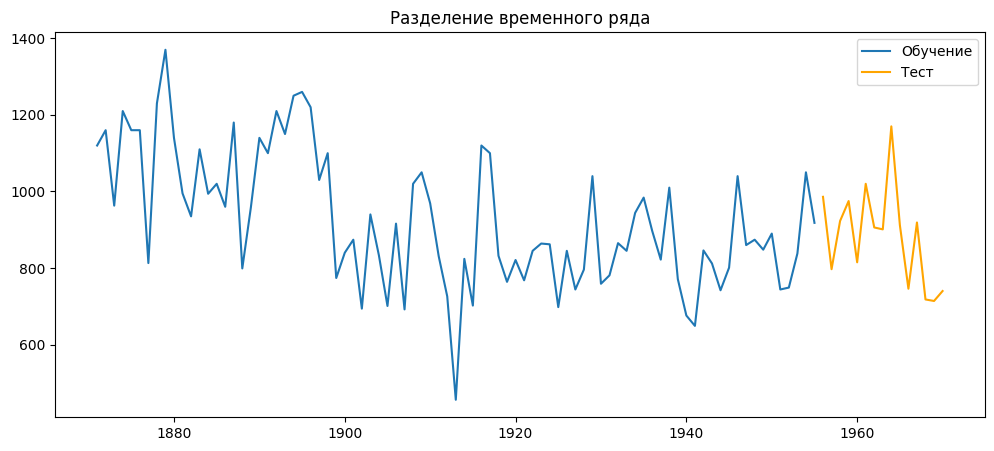

In [4]:
test_size = 15
train_ts = ts[:-test_size]
test_ts = ts[-test_size:]

plt.figure(figsize=(12, 5))
plt.plot(train_ts, label='Обучение')
plt.plot(test_ts, label='Тест', color='orange')
plt.title('Разделение временного ряда')
plt.legend()
plt.show()

# Прогнозирование методом ARIMA
Используем модель ARIMA(1, 1, 1), так как ряд имеет трендовые колебания и зависимости от предыдущих значений.

In [5]:
# Обучение и прогноз
model_arima = ARIMA(train_ts, order=(1, 1, 1))
res_arima = model_arima.fit()
pred_arima = res_arima.forecast(steps=test_size)

/home/andrey/university/ml_6_sem/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/home/andrey/university/ml_6_sem/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/home/andrey/university/ml_6_sem/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)


# Подготовка признаков для машинного обучения
Для регрессионных моделей создадим признаки на основе 3-х предыдущих значений ряда (лагов).

In [6]:
def create_features(series, lags=3):
    df = series.to_frame()
    col_name = df.columns[0]
    df.columns = ['target']
    for i in range(1, lags + 1):
        df[f'lag_{i}'] = df['target'].shift(i)
    return df.dropna()

# Формирование датасета
df_ml = create_features(ts, lags=3)

# Разделение по дате, соответствующей началу тестовой выборки
X = df_ml.drop('target', axis=1)
y = df_ml['target']

X_train = X[X.index < test_ts.index[0]]
y_train = y[y.index < test_ts.index[0]]
X_test = X[X.index >= test_ts.index[0]]
y_test = y[y.index >= test_ts.index[0]]

# Символьная регрессия
Модель генетического программирования для поиска аналитической зависимости.

In [7]:
model_sr = SymbolicRegressor(
    population_size=1000,
    generations=15,
    random_state=42,
    verbose=0
)
model_sr.fit(X_train, y_train)
pred_sr = model_sr.predict(X_test)

# Линейный и нелинейный методы (Замена GMDH)
Используем Линейную регрессию и Случайный лес как альтернативу методам COMBI и MIA.

In [8]:
# Линейная регрессия
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
pred_lr = model_lr.predict(X_test)

# Случайный лес
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)
pred_rf = model_rf.predict(X_test)

# Визуализация результатов и оценка качества
Сравним все полученные прогнозы с реальными данными.

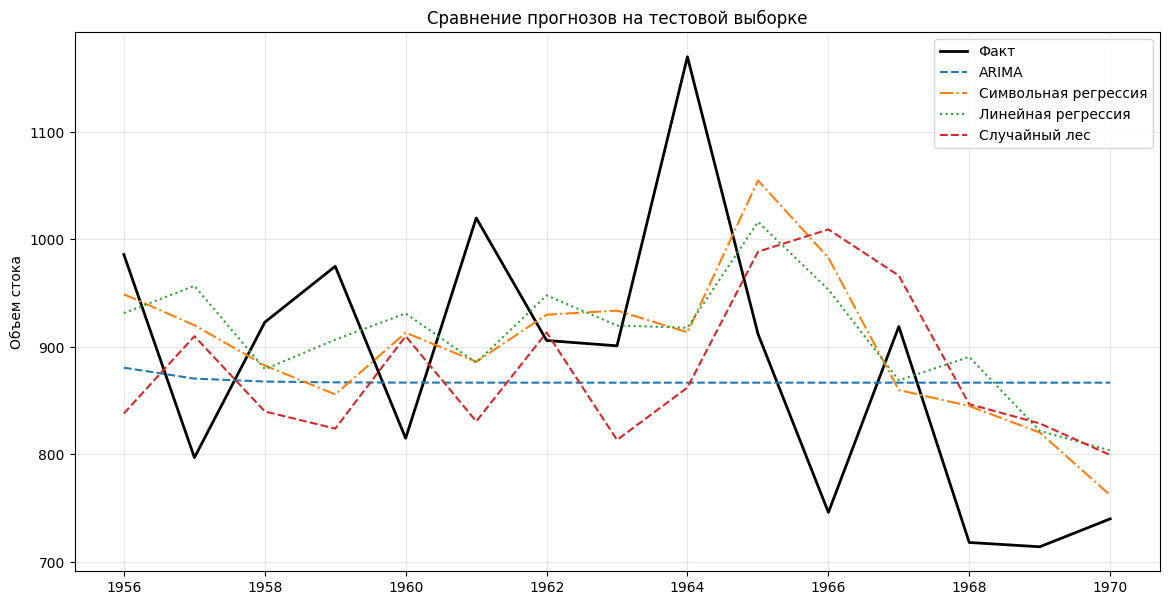

Метрики точности прогнозирования:
ARIMA: MAE=104.70, RMSE=124.62, MAPE=0.1190
Символьная регрессия: MAE=103.94, RMSE=125.24, MAPE=0.1191
Линейная регрессия: MAE=106.41, RMSE=124.98, MAPE=0.1237
Случайный лес: MAE=124.82, RMSE=146.61, MAPE=0.1411


In [9]:
plt.figure(figsize=(14, 7))
plt.plot(test_ts.index, test_ts.values, label='Факт', color='black', linewidth=2)
plt.plot(test_ts.index, pred_arima.values, label='ARIMA', linestyle='--')
plt.plot(y_test.index, pred_sr, label='Символьная регрессия', linestyle='-.')
plt.plot(y_test.index, pred_lr, label='Линейная регрессия', linestyle=':')
plt.plot(y_test.index, pred_rf, label='Случайный лес', linestyle='--')

plt.title('Сравнение прогнозов на тестовой выборке')
plt.ylabel('Объем стока')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

def get_metrics(true, pred, name):
    mae = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    mape = mean_absolute_percentage_error(true, pred)
    print(f"{name}: MAE={mae:.2f}, RMSE={rmse:.2f}, MAPE={mape:.4f}")

print("Метрики точности прогнозирования:")
get_metrics(test_ts, pred_arima, "ARIMA")
get_metrics(y_test, pred_sr, "Символьная регрессия")
get_metrics(y_test, pred_lr, "Линейная регрессия")
get_metrics(y_test, pred_rf, "Случайный лес")